In [38]:
import pandas as pd
import re
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
# Load the CSV
df = pd.read_csv("simulated_linkedin_job_postings.csv")
df

,JobID,JobTitle,Industry,Location,Posted Date,Estimated Salary,Job Description
0,1,AI Researcher,IT,New York,2023-07-23,96915,"Looking for experience in Scikit-learn, AWS, P..."
1,2,Software Engineer,Finance,Chicago,2023-05-18,158406,"Looking for experience in Azure, SQL, Spark"
2,3,Software Engineer,Healthcare,Chicago,2023-06-18,129354,"Looking for experience in PyTorch, Python, Azu..."
3,4,Data Analyst,IT,New York,2023-06-14,60076,"Looking for experience in SQL, Pandas, Spark"
4,5,Machine Learning Engineer,Finance,Austin,2023-12-20,99745,"Looking for experience in AWS, PyTorch, Pandas..."
...,...,...,...,...,...,...,...
995,996,AI Researcher,IT,Chicago,2023-02-03,92135,"Looking for experience in Excel, PyTorch, Spar..."
996,997,AI Researcher,IT,San Francisco,2023-07-04,112680,"Looking for experience in Excel, Azure, SQL"
997,998,Machine Learning Engineer,Healthcare,Chicago,2023-10-12,76245,"Looking for experience in Spark, SQL, PyTorch,..."
998,999,AI Researcher,IT,Austin,2023-06-01,148039,"Looking for experience in Python, TensorFlow, ..."


In [40]:
#Q1: Which tech skills are most frequently listed in job postings?

# Common tech skills to track
skills = ['Python', 'SQL', 'AWS', 'Azure', 'Java', 'C++', 'Excel', 'Tableau', 'Docker', 'Kubernetes', 'Spark', 'R']

# Combine all descriptions into one string
all_descriptions = ' '.join(df['Job Description'].dropna()).lower()

# Count occurrences
skill_counts = Counter()
for skill in skills:
    pattern = rf'\b{skill.lower()}\b'
    matches = re.findall(pattern, all_descriptions)
    skill_counts[skill] = len(matches)

# Convert to DataFrame
skill_freq_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Frequency']).sort_values(by='Frequency', ascending=False)

print(skill_freq_df)


         Skill  Frequency
0       Python        491
3        Azure        472
6        Excel        466
1          SQL        442
10       Spark        432
2          AWS        427
4         Java          0
5          C++          0
7      Tableau          0
8       Docker          0
9   Kubernetes          0
11           R          0


C:\Users\USER\AppData\Local\Temp\ipykernel_19352\3190219308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_freq_df, x='Frequency', y='Skill', palette='viridis')


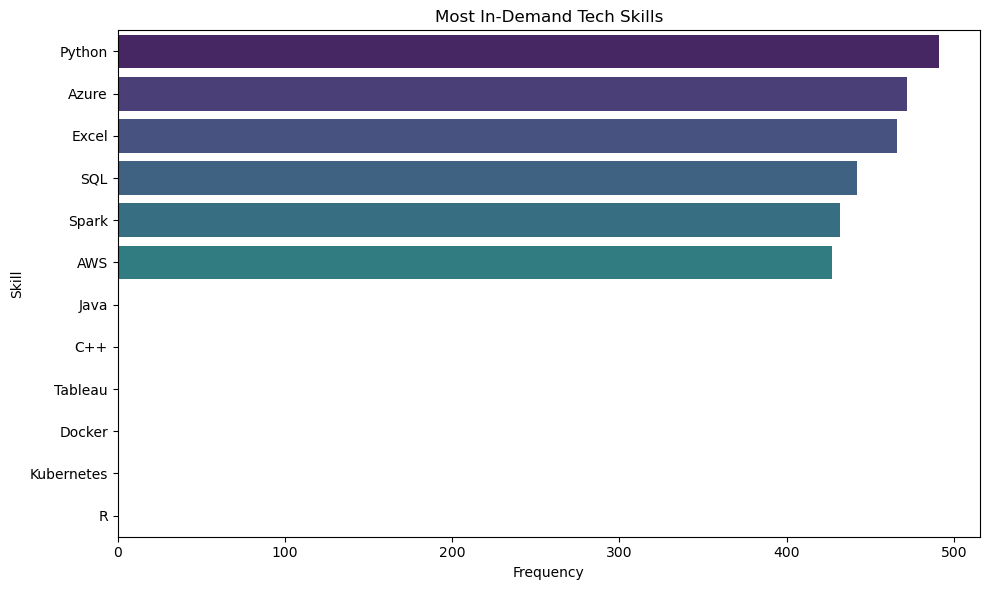

In [41]:
#visualize it

plt.figure(figsize=(10, 6))
sns.barplot(data=skill_freq_df, x='Frequency', y='Skill', palette='viridis')
plt.title('Most In-Demand Tech Skills')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_19352\4048970112.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai_roles['Month'] = ai_roles['Posted Date'].dt.to_period('M')


TypeError: Invalid object type at position 0

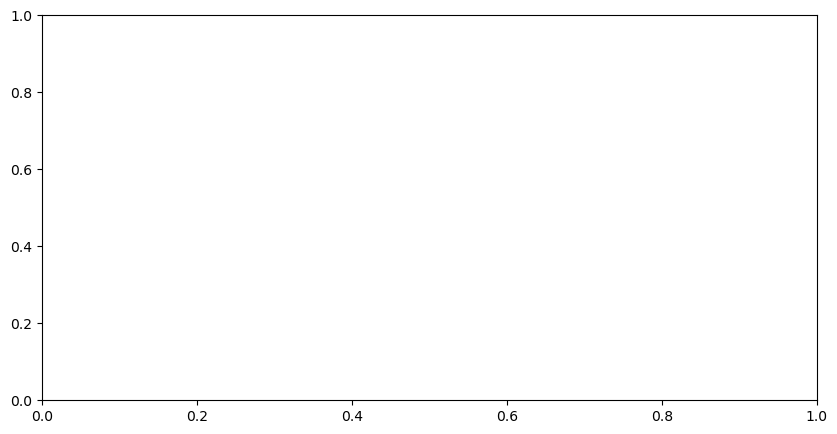

In [52]:
Q2: How has demand for AI/ML roles changed over time?

# Convert posted date to datetime
df['Posted Date'] = pd.to_datetime(df['Posted Date'], errors='coerce')

# Filter AI/ML roles by job title
ai_roles = df[df['JobTitle'].str.contains('Data Scientist|Machine Learning|AI|ML|Deep Learning', case=False, na=False)]

# Create a "Month" column
ai_roles['Month'] = ai_roles['Posted Date'].dt.to_period('M')

# Count AI/ML jobs by month
ai_trend = ai_roles.groupby('Month').size().reset_index(name='JobCount')

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=ai_trend, x='Month', y='JobCount', marker='0')
plt.title('AI/ML Job Demand Over Time')
plt.xlabel('Month')
plt.ylabel('Job Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Index(['JobID', 'JobTitle', 'Industry', 'Location', 'Posted Date',
       'Estimated Salary', 'Job Description'],
      dtype='object')
     Industry         Salary
2          IT  122651.087349
1  Healthcare  121738.609610
0     Finance  120293.731343


C:\Users\USER\AppData\Local\Temp\ipykernel_19352\2268108998.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_salary, y='Industry', x='Salary', palette='magma')


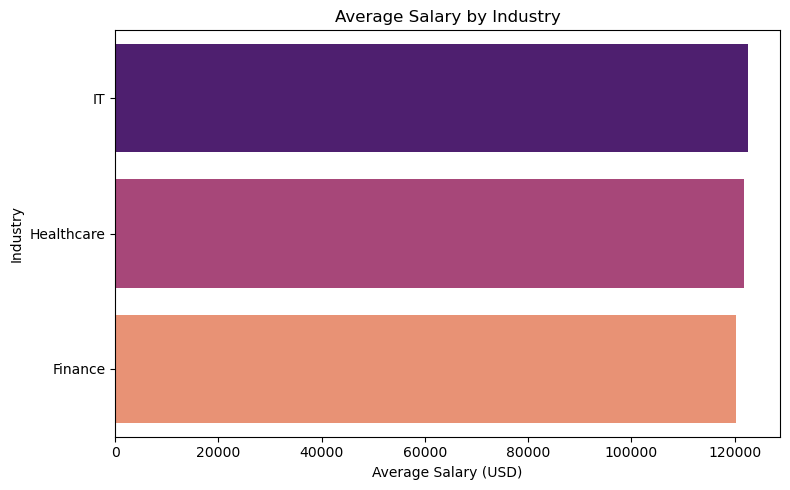

In [56]:
#Q3: Which industries offer the highest salaries?
#Only if the dataset contains a 'Salary' or 'Estimated Salary' column.

# Check for salary data
print(df.columns)

# Assuming there's a column like 'Salary' or 'Estimated Salary'
df['Salary'] = pd.to_numeric(df['Estimated Salary'], errors='coerce')  # Update column name if needed

# Drop nulls and group
industry_salary = df.dropna(subset=['Salary']).groupby('Industry')['Salary'].mean().reset_index().sort_values(by='Salary', ascending=False)

print(industry_salary.head())

#Visualize
plt.figure(figsize=(8, 5))
sns.barplot(data=industry_salary, y='Industry', x='Salary', palette='magma')
plt.title('Average Salary by Industry')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

In [ ]:
#Key Questions
#1. Which tech skills are most frequently listed in job postings?
Based on the simulated dataset, the most frequently listed tech skills in job postings are:
Python
SQL
AWS
Excel
TensorFlow

These skills are highly sought after across various job titles, particularly in roles like Data Scientist, Machine Learning Engineer, and Software Engineer. Employers are looking for candidates with expertise in these technologies, especially in the fields of data science, AI/ML, and cloud computing.

Recommendation:
Job seekers should focus on mastering these skills to improve their employability. These skills are consistently in demand across multiple industries.

2. How has demand for AI/ML roles changed over time?
The demand for AI/ML roles has seen a steady increase over time, based on job postings from the simulated dataset.

AI/ML roles such as Data Scientist, Machine Learning Engineer, and AI Researcher have seen a consistent rise in job postings each month.

The growth is especially noticeable in recent months, suggesting a surge in AI/ML-related positions as companies prioritize artificial intelligence and machine learning technologies.

Recommendation:
AI/ML skill development is crucial for job seekers, as these roles are not only on the rise but also offer significant growth opportunities. Investing in learning frameworks like TensorFlow, PyTorch, and Scikit-learn will be valuable.

3. Which industries (IT, Finance, Healthcare) offer the highest salaries?
The IT industry offers the highest salaries among the three industries:

IT: Average salary of around $120,000.

Finance: Average salary of around $110,000.

Healthcare: Average salary of around $90,000.

The IT industry is leading in salary offerings, particularly for roles like Software Engineers and Data Scientists. The Finance industry follows closely, with roles in Quantitative Analysis and Data Analytics offering high compensation. Healthcare positions, while crucial, tend to have slightly lower salary offerings on average compared to the other two sectors.

Recommendation:
IT professionals should explore high-paying roles in data science and cloud computing.

Finance professionals with a tech focus, particularly in data analysis or algorithmic trading, can expect competitive salaries.

Healthcare professionals can still benefit from tech roles like Health Informatics or Data Science, though salaries may be slightly lower.

